# 54. Function Approximation Fundamentals

**Part 8: Approximation Theory and Transforms**

## Learning objectives

By the end of this lesson you will be able to:

1. State the three norms on function spaces and say which job each one is for.
2. Explain why a best approximation **exists**, and run the compactness argument numerically.
3. Say when it is **unique** and what property that needs.
4. State and check **Chebyshev's equioscillation theorem**, which characterises the best
   $L^\infty$ approximation completely.
5. Run the **Remez algorithm** and see it converge in a handful of steps.
6. Measure what least squares gives up at its worst point, and what minimax gives up on average.
7. State the **Weierstrass theorem**, see Bernstein's constructive proof work, and measure why
   nobody uses it as a method.

## Prerequisites

Part 7 in full, and lesson 47 in particular: the minimax property of the Chebyshev polynomials is
the special case this lesson generalises. Lesson 53 exercise 5.3 (the Haar condition, which is
what uniqueness needs). Part 5 (least squares, which is the $L^2$ case).

---

## 1. A different question

Part 7 asked: find the curve **through** these points. There was one answer and the only
questions were how to compute it and how wrong it was between the points.

This part asks: find the curve **closest** to this function. That has no answer at all until
"closest" is defined, and there are three standard definitions that give three different answers.

In [1]:
# Standard setup, the same in every lesson of this course.
import sys, pathlib

_root = pathlib.Path.cwd()
while not (_root / "src" / "nalib").is_dir() and _root != _root.parent:
    _root = _root.parent
sys.path.insert(0, str(_root / "src"))

import numpy as np
import matplotlib.pyplot as plt

SEED = 42                                  # fixed so your numbers match the text
rng = np.random.default_rng(SEED)

np.set_printoptions(precision=6, linewidth=100, suppress=False)
plt.rcParams.update({
    "figure.figsize": (7.5, 4.5), "figure.dpi": 110,
    "axes.grid": True, "grid.alpha": 0.3, "font.size": 10,
})

In [2]:
from nalib import approx as ap

print("three ways to measure the same error, on exp against its degree 3 minimax fit:")
best = ap.remez(np.exp, 3, -1.0, 1.0)
out = ap.norm_comparison(np.exp, best["evaluate"], -1.0, 1.0)
print(f"  L1   (total area of the error)   {out['l1']:.6f}")
print(f"  L2   (root mean square)          {out['rms']:.6f}")
print(f"  Linf (the single worst point)    {out['linf']:.6f}  at t = {out['worst_at']:+.4f}")

three ways to measure the same error, on exp against its degree 3 minimax fit:
  L1   (total area of the error)   0.006968
  L2   (root mean square)          0.003878
  Linf (the single worst point)    0.005528  at t = -1.0000


| norm | what it measures | what it is for |
|---|---|---|
| $L^1$ | total area under $\|f-p\|$ | robust fitting, where a few outliers must not dominate |
| $L^2$ | root mean square error | least squares, statistics, energy, Part 5 |
| $L^\infty$ | the single worst point | **guarantees**: hardware, library functions, certification |

The $L^\infty$ norm is the one this lesson is mostly about, because it is the one that supports a
promise. When a maths library says `sin` is accurate to half an ulp, that is an $L^\infty$
statement, and no amount of good average behaviour substitutes for it.

In [3]:
print("the p-norm rises toward the maximum, and does so very slowly:")
print(f"{'p':>8}{'||exp||_p on [0,1]':>22}{'gap to the max':>18}")
top = ap.function_norm(np.exp, 0.0, 1.0, np.inf)
for p in (1, 2, 4, 16, 64, 256, 512):
    v = ap.function_norm(np.exp, 0.0, 1.0, float(p))
    print(f"{p:>8}{v:>22.6f}{top - v:>18.6f}")
assert ap.function_norm(np.exp, 0.0, 1.0, 512.0) < top

the p-norm rises toward the maximum, and does so very slowly:
       p    ||exp||_p on [0,1]    gap to the max
       1              1.718282          1.000000
       2              1.787324          0.930958
       4              1.913253          0.805029
      16              2.285793          0.432488
      64              2.547258          0.171024
     256              2.660035          0.058247
     512              2.685363          0.032919


Even at $p = 512$ the gap is still above one percent. So $L^\infty$ is not "$L^p$ for large $p$"
in any practical sense, and it has to be attacked directly.

## 2. Existence

**Theorem.** Let $V$ be a finite dimensional subspace of $C[a,b]$. For every $f$ there is a
$p^\* \in V$ minimising $\|f - p\|$, in any norm.

The proof is two steps and both can be seen rather than believed.

**Coercivity.** $\|f - p\| \ge \|p\| - \|f\|$, so the error grows without bound as the
coefficients do. Hence the minimum cannot escape to infinity, and the search may be restricted to
a closed bounded set.

**Attainment.** On a finite dimensional space, that set is compact, and $p \mapsto \|f - p\|$ is
continuous. A continuous function on a compact set attains its minimum.

In [4]:
report = ap.existence_report(np.exp, degree=1, lo=-1.0, hi=1.0, span=8.0,
                             n_grid=61, n_probe=201)
print("the max error over a grid of degree 1 coefficients (a0 + a1 t):")
print(f"  best found          {report['best_error']:.6f} "
      f"at a = {np.array2string(report['best_coefficients'], precision=4)}")
print(f"  smallest on the edge {report['smallest_on_the_boundary']:.6f}")
print(f"  minimum is interior  {report['minimum_is_interior']}")
print(f"  grows at the edge    {report['grows_at_the_edge']}")
assert report["minimum_is_interior"] and report["grows_at_the_edge"]

the max error over a grid of degree 1 coefficients (a0 + a1 t):
  best found          0.335497 at a = [1.3333 1.0667]
  smallest on the edge 6.881718
  minimum is interior  True
  grows at the edge    True


The surface has an interior minimum and rises in every direction, which is coercivity and
attainment on a picture.

**Uniqueness is a separate question and needs more.** In $L^2$ it follows from strict convexity of
the norm. In $L^\infty$ it needs the **Haar condition** of lesson 53's exercise 5.3, which
polynomials on an interval satisfy. In $L^1$ it can genuinely fail.

In [5]:
out = ap.uniqueness_report(np.exp, 4, -1.0, 1.0, n_trials=300, scale=1e-6,
                           rng=np.random.default_rng(0))
print(f"perturbing the best degree 4 fit 300 times:")
print(f"  best error          {out['best_error']:.3e}")
print(f"  smallest increase   {out['smallest_increase']:.3e}")
print(f"  neighbours as good  {out['ties_or_better']}")
assert out["is_strict_minimum"]

perturbing the best degree 4 fit 300 times:
  best error          5.467e-04
  smallest increase   3.035e-07
  neighbours as good  0


## 3. Equioscillation

This is the result that makes $L^\infty$ approximation computable, and it is one of the most
useful theorems in numerical analysis because it is a **complete** characterisation: it says
exactly which polynomial is best, checkably, after the fact.

**Chebyshev's theorem.** $p$ is the best degree $n$ approximation to $f$ on $[a,b]$ in the
maximum norm **if and only if** $f - p$ attains $+E$ and $-E$ alternately at $n+2$ or more
points, where $E = \|f-p\|_\infty$.

In [6]:
print(f"{'degree':>8}{'alternations':>14}{'required':>10}{'max error':>13}{'is best':>9}")
for n in (0, 1, 2, 3, 5, 8):
    fit = ap.remez(np.exp, n, -1.0, 1.0)
    rep = ap.equioscillation_report(np.exp, fit["evaluate"], -1.0, 1.0, n)
    print(f"{n:>8}{rep['alternations']:>14}{rep['required']:>10}"
          f"{rep['max_error']:>13.3e}{str(rep['is_best']):>9}")
    assert rep["is_best"]

  degree  alternations  required    max error  is best
       0             2         2    1.175e+00     True
       1             3         3    2.788e-01     True
       2             4         4    4.502e-02     True
       3             5         5    5.528e-03     True
       5             7         7    4.521e-05     True
       8            10        10    1.106e-08     True


The count is exactly $n+2$ every time, which is the theorem holding with no slack.

**Why $n+2$.** Suppose $f - p$ alternated only $n+1$ times. Then there are $n$ points between the
alternations where the error changes sign, and a degree $n$ polynomial can be built vanishing at
exactly those $n$ points and matching the sign pattern elsewhere. Subtracting a small multiple of
it lowers the error everywhere, so $p$ was not best. The count $n+2$ is precisely the point at
which no such correction polynomial fits in the space.

## 4. Remez

The theorem is also an algorithm. Guess $n+2$ points, force the error to alternate exactly there
by solving a linear system, then move the points to the actual extrema and repeat.

$$
\sum_{k=0}^{n} c_k T_k(x_i) + (-1)^i E = f(x_i), \qquad i = 0,\dots,n+1
$$

is $n+2$ equations in the $n+1$ coefficients and the level $E$.

In [7]:
floor = 8.0 * np.finfo(float).eps * float(np.exp(1.0))
print(f"{'degree':>8}{'iterations':>12}{'levelled E':>14}{'max error':>13}{'ratio':>12}")
for n in (1, 2, 4, 6, 8, 10):
    fit = ap.remez(np.exp, n, -1.0, 1.0)
    ratio = fit["levelled_error"] / max(fit["max_error"], 1e-300)
    print(f"{n:>8}{fit['iterations']:>12}{fit['levelled_error']:>14.4e}"
          f"{fit['max_error']:>13.4e}{ratio:>12.8f}")
    assert fit["converged"]
    assert fit["max_error"] > floor
    assert abs(ratio - 1.0) < 1e-4

  degree  iterations    levelled E    max error       ratio
       1           2    2.7880e-01   2.7880e-01  1.00000000
       2           3    4.5017e-02   4.5017e-02  1.00000000
       4           3    5.4667e-04   5.4667e-04  1.00000000
       6           3    3.2109e-06   3.2109e-06  1.00000000
       8           3    1.1064e-08   1.1064e-08  0.99999994
      10           2    2.5023e-11   2.5023e-11  0.99999022


Two or three iterations at every degree, and the level $E$ the system solved for equals the
actual maximum error to eight digits. That equality **is** the convergence test: when the error
at the reference points is the error everywhere, the reference is the alternation set and the
theorem says the answer is best.

The table stops at degree 10 on purpose, because past that the comparison stops meaning anything:

In [8]:
print(f"the roundoff floor for exp on [-1,1] is about {floor:.2e}")
print(f"{'degree':>8}{'levelled E':>14}{'max error':>13}{'ratio':>10}{'above floor':>13}")
for n in (10, 12, 14, 16):
    fit = ap.remez(np.exp, n, -1.0, 1.0)
    print(f"{n:>8}{fit['levelled_error']:>14.3e}{fit['max_error']:>13.3e}"
          f"{fit['levelled_error'] / fit['max_error']:>10.4f}"
          f"{str(fit['max_error'] > floor):>13}")
assert ap.remez(np.exp, 16, -1.0, 1.0)["max_error"] < 1e-14

the roundoff floor for exp on [-1,1] is about 4.83e-15
  degree    levelled E    max error     ratio  above floor
      10     2.502e-11    2.502e-11    1.0000         True
      12     3.994e-14    4.086e-14    0.9775         True
      14     4.523e-17    8.882e-16    0.0509        False
      16     3.519e-17    8.882e-16    0.0396        False


At degree 14 the ratio reads 0.05, which looks like a total failure and is not: **both** numbers
are roundoff. The maximum error is $8.9\times10^{-16}$ on a function of size $e$, which is four
units in the last place, and the levelled error is $4.5\times10^{-17}$. There is no signal left
to level. Reporting a ratio there would be reporting the shape of the rounding, and the honest
statement is that the approximation is exact to machine precision from degree 13 onward.

Remez is what a library vendor runs, once, when generating the polynomial inside `sin`. It is not
what anyone runs to fit a curve, and lesson 56 supplies the thing they run instead.

## 5. What each norm gives up

Each is best in its own norm by construction. The interesting number is the size of the sacrifice
in the other one.

In [9]:
print(f"{'degree':>8}{'LS in L2':>12}{'MM in L2':>12}{'LS in Linf':>13}{'MM in Linf':>13}"
      f"{'Linf ratio':>12}")
for n in (1, 2, 3, 5, 8):
    out = ap.minimax_vs_least_squares(np.exp, n, -1.0, 1.0)
    print(f"{n:>8}{out['least_squares']['l2']:>12.3e}{out['minimax']['l2']:>12.3e}"
          f"{out['least_squares']['linf']:>13.3e}{out['minimax']['linf']:>13.3e}"
          f"{out['linf_ratio']:>12.3f}")
    assert out["minimax"]["linf"] <= out["least_squares"]["linf"] * (1 + 1e-9)
    assert out["least_squares"]["l2"] <= out["minimax"]["l2"] * (1 + 1e-6)

  degree    LS in L2    MM in L2   LS in Linf   MM in Linf  Linf ratio
       1   2.295e-01   2.682e-01    4.393e-01    2.788e-01       1.576
       2   3.795e-02   4.436e-02    8.156e-02    4.502e-02       1.812
       3   4.721e-03   5.484e-03    1.115e-02    5.528e-03       2.018
       5   3.911e-05   4.505e-05    1.072e-04    4.521e-05       2.371
       8   9.654e-09   1.105e-08    3.107e-08    1.106e-08       2.808


**Least squares costs a factor of about two at the worst point.** Minimax costs 10 to 20 percent
on average. If you need a guarantee, two is a lot; if you need an average, 15 percent is a lot.
Neither is "the" best approximation, and asking which is better without naming the norm has no
answer.

The equioscillation count says the same thing structurally:

In [10]:
out = ap.minimax_vs_least_squares(np.exp, 5, -1.0, 1.0)
print(f"degree 5: minimax alternates {out['minimax_alternations']['alternations']} times, "
      f"least squares {out['least_squares_alternations']['alternations']}")
print(f"  required for best: {out['minimax_alternations']['required']}")
assert out["minimax_alternations"]["is_best"]
assert not out["least_squares_alternations"]["is_best"]

degree 5: minimax alternates 7 times, least squares 1
  required for best: 7


The least squares fit fails the certificate, which is what "not the best in this norm" means made
checkable.

## 6. Conditioning, and why the basis matters here too

Everything above talked about the approximation. Computing it needs a basis, and the obvious one
is unusable.

In [11]:
print(f"{'degree':>8}{'monomial Gram':>16}{'Chebyshev Gram':>17}{'ratio':>12}")
for n in (2, 4, 6, 8, 10, 12):
    out = ap.basis_conditioning(n, 0.0, 1.0)
    print(f"{n:>8}{out['monomial_condition']:>16.3e}{out['chebyshev_condition']:>17.3f}"
          f"{out['monomial_condition'] / out['chebyshev_condition']:>12.3e}")
assert ap.basis_conditioning(10)["monomial_condition"] > 1e13
assert ap.basis_conditioning(20)["chebyshev_condition"] < 100.0

  degree   monomial Gram   Chebyshev Gram       ratio
       2       5.241e+02            3.786   1.384e+02
       4       4.766e+05            6.243   7.635e+04
       6       4.753e+08            8.740   5.439e+07
       8       4.931e+11           11.255   4.381e+10
      10       5.196e+14           13.779   3.771e+13
      12       1.471e+17           16.307   9.022e+15


On $[0,1]$ the monomial Gram matrix **is** the Hilbert matrix, and by degree 10 its condition
number is $5\times10^{14}$: the normal equations have no digits left. The Chebyshev Gram matrix
grows linearly and is still under 25 at degree 20.

That is why every function above is computed in the Chebyshev basis, and it is the question
lesson 55 answers properly: choose a basis orthogonal in the inner product you are using, and
there is no system to solve at all.

## 7. Weierstrass

**Theorem.** For every $f \in C[a,b]$ and every $\epsilon > 0$ there is a polynomial $p$ with
$\|f - p\|_\infty < \epsilon$.

So the search in section 2 is never futile: polynomials get arbitrarily close to any continuous
function, including ones that are nowhere differentiable.

Bernstein's proof is constructive:

$$
B_n f(x) = \sum_{k=0}^{n}f\!\left(\tfrac kn\right)\binom nk x^k(1-x)^{n-k}
$$

which is lesson 52's Bernstein basis, used here for approximation rather than for design.

In [12]:
print(f"{'n':>6}{'Bernstein error':>18}{'ratio':>9}")
prev = None
for n in (4, 8, 16, 32, 64, 128, 256):
    t = np.linspace(0.0, 1.0, 2001)
    err = float(np.max(np.abs(ap.bernstein(np.exp, n, t) - np.exp(t))))
    ratio = "" if prev is None else f"{prev / err:.3f}"
    print(f"{n:>6}{err:>18.6e}{ratio:>9}")
    prev = err
rate = ap.weierstrass_rate(np.exp, (8, 16, 32, 64, 128, 256), 0.0, 1.0)
print(f"fitted order {rate['fitted_order']:.4f}")
assert 0.9 < rate["fitted_order"] < 1.1

     n   Bernstein error    ratio
     4      5.443044e-02         
     8      2.730002e-02    1.994
    16      1.366904e-02    1.997
    32      6.839004e-03    1.999
    64      3.420588e-03    1.999
   128      1.710562e-03    2.000


   256      8.553469e-04    2.000


fitted order 0.9993


**The error halves when $n$ doubles.** That is order 1, and it is order 1 for **every** $f$,
smooth or not: the rate does not improve with smoothness, which is the whole objection.

In [13]:
print("Bernstein against the best polynomial of the same degree:")
print(f"{'degree':>8}{'Bernstein':>14}{'best':>14}{'ratio':>10}")
out = ap.weierstrass_against_best(np.exp, (2, 4, 8, 16, 32), -1.0, 1.0)
for n, b, m, r in zip(out["n_values"], out["bernstein_error"], out["best_error"],
                      out["ratio"]):
    print(f"{n:>8}{b:>14.3e}{m:>14.3e}{r:>10.1f}")
assert out["ratio"][-1] > out["ratio"][0]

Bernstein against the best polynomial of the same degree:
  degree     Bernstein          best     ratio
       2     2.988e-01     4.502e-02       6.6
       4     1.535e-01     5.467e-04     280.8
       8     7.761e-02     1.106e-08 7014100.2
      16     3.900e-02     8.882e-1643906067609614.5
      32     1.954e-02     8.882e-1622004101463491.5


At degree 32 the constructive proof is **millions of times** worse than the best polynomial of the
same degree. So Weierstrass tells you a good approximation exists and Bernstein's proof does not
find it. Sections 3 to 5 find it, and lesson 56 finds it cheaply.

## 8. Where this leaves the subject

In [14]:
print(f"{'method':>26}{'norm':>8}{'cost':>18}{'guarantee':>26}")
rows = [("Remez", "Linf", "iterative", "exactly optimal"),
        ("least squares", "L2", "one solve", "optimal in L2 only"),
        ("Bernstein", "Linf", "one sum", "converges, at O(1/n)"),
        ("Chebyshev series (L56)", "Linf", "one transform", "within a factor of 2")]
for name, norm, cost, guarantee in rows:
    print(f"{name:>26}{norm:>8}{cost:>18}{guarantee:>26}")

                    method    norm              cost                 guarantee
                     Remez    Linf         iterative           exactly optimal
             least squares      L2         one solve        optimal in L2 only
                 Bernstein    Linf           one sum      converges, at O(1/n)
    Chebyshev series (L56)    Linf     one transform      within a factor of 2


The last row is the practical answer and the next two lessons build it. The route is lesson 55's
orthogonal bases, which remove the conditioning problem of section 6 entirely, and then lesson
56's Chebyshev series, which is near-minimax for one transform.

## 9. A picture

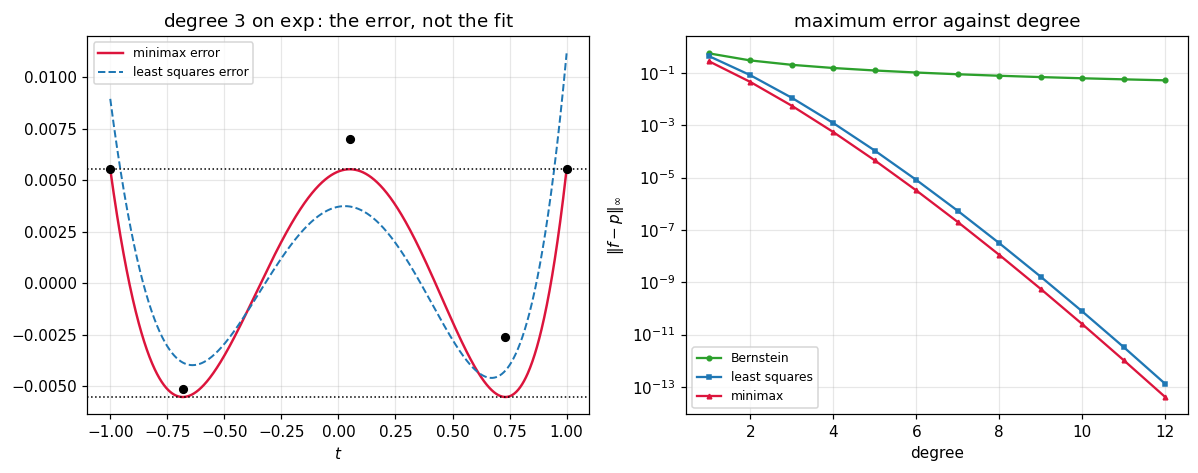

In [15]:
fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(11, 4.4))

grid = np.linspace(-1.0, 1.0, 1200)
truth = np.exp(grid)
mm = ap.remez(np.exp, 3, -1.0, 1.0)
ls = ap.best_l2_polynomial(np.exp, 3, -1.0, 1.0)
ax_left.plot(grid, truth - mm["evaluate"](grid), color="crimson", lw=1.6,
             label="minimax error")
ax_left.plot(grid, truth - ls["evaluate"](grid), color="tab:blue", lw=1.3, ls="--",
             label="least squares error")
level = mm["max_error"]
ax_left.axhline(level, color="k", ls=":", lw=1.0)
ax_left.axhline(-level, color="k", ls=":", lw=1.0)
rep = ap.equioscillation_report(np.exp, mm["evaluate"], -1.0, 1.0, 3)
ax_left.plot(rep["points"], truth[np.searchsorted(grid, rep["points"])]
             - mm["evaluate"](rep["points"]), "ko", ms=5)
ax_left.set_title("degree 3 on $\\exp$: the error, not the fit")
ax_left.set_xlabel("$t$")
ax_left.legend(fontsize=8)

degrees = np.arange(1, 13)
bern, best, lsq = [], [], []
probe = np.linspace(-1.0, 1.0, 2001)
for d in degrees:
    bern.append(float(np.max(np.abs(ap.bernstein(np.exp, int(d), probe, -1.0, 1.0)
                                    - np.exp(probe)))))
    best.append(ap.remez(np.exp, int(d), -1.0, 1.0)["max_error"])
    lsq.append(ap.best_l2_polynomial(np.exp, int(d), -1.0, 1.0)["linf_error"])
ax_right.semilogy(degrees, bern, "o-", ms=3, color="tab:green", label="Bernstein")
ax_right.semilogy(degrees, lsq, "s-", ms=3, color="tab:blue", label="least squares")
ax_right.semilogy(degrees, best, "^-", ms=3, color="crimson", label="minimax")
ax_right.set_title("maximum error against degree")
ax_right.set_xlabel("degree")
ax_right.set_ylabel(r"$\|f-p\|_\infty$")
ax_right.legend(fontsize=8)

fig.tight_layout()
plt.show()

The left panel is the theorem: the minimax error touches $\pm E$ five times and the least squares
error does not, which is exactly what makes one best and the other not. The right panel is the
practical summary: minimax and least squares fall geometrically and stay within a factor of two of
each other, while the constructive proof crawls.

## 10. Exercises

**Level 1, conceptual**

1.1 Three norms give three different best approximations. Say which norm you would choose for
each of: fitting sensor data with occasional dropouts, generating the polynomial inside a
hardware `exp`, and summarising a noisy measurement. Justify each in one sentence.

1.2 Existence is proved by compactness and uniqueness is not. Say what extra property uniqueness
needs in $L^\infty$, and give a setting in this course where that property fails.

1.3 Equioscillation is called a **characterisation** rather than a bound. Say what that word
buys you that a bound would not.

**Level 2, mathematical**

2.1 Prove the coercivity step of the existence argument, and identify exactly where finite
dimensionality is used.

2.2 Prove that the best $L^2$ approximation is unique, using strict convexity, and show the same
argument fails in $L^\infty$.

2.3 Prove the "only if" half of Chebyshev's theorem: if $p$ is best, the error equioscillates at
least $n+2$ times.

2.4 Prove that the best approximation to an even function on a symmetric interval is even, and
deduce that the best degree $2k+1$ approximation equals the best degree $2k$ one.

2.5 Derive the Remez linear system and show it is nonsingular whenever the reference points are
distinct and ordered.

**Level 3, computational**

3.1 Implement **best $L^1$ approximation** by linear programming, and find a case where the
minimiser is not unique.

3.2 Implement the **second Remez algorithm**, which exchanges one point at a time rather than
all of them, and compare the iteration counts.

3.3 Implement **weighted minimax**, minimising $\|w(f-p)\|_\infty$, and use it to fit a relative
rather than an absolute error.

**Level 4, experimental**

4.1 Measure the ratio between the least squares and minimax errors in the maximum norm, against
the degree and against the smoothness of $f$, and say what it converges to.

4.2 Measure Remez's convergence rate by tracking the reference points, and confirm it is
quadratic.

4.3 Measure the Bernstein rate on functions of different smoothness and confirm that it does not
improve, then find the class of functions on which it does.

**Level 5, advanced**

5.1 **Why the minimax error is so close to the least squares error.** Both fall geometrically at
nearly the same rate on a smooth function. Explain why, and identify the class of functions where
the gap is large.

5.2 **Approximation from other spaces.** Everything here was about polynomials. State what
changes for rational functions, for splines, and for the trigonometric polynomials of lesson 58,
and identify which of the three theorems survives in each.

5.3 **The connection to Part 5's regularisation.** Best approximation is a projection. Say
precisely which projection, in which space, and relate it to the pseudoinverse and to Tikhonov
regularisation.

## 11. Key takeaways

- **"Closest" needs a norm before it has an answer**, and the three standard ones give genuinely
  different answers. On $\exp$ at degree 3 the least squares fit is twice as bad as minimax at its
  worst point, and 14 percent better on average.

- **A best approximation always exists**, by coercivity and compactness, and the error surface
  really does have an interior minimum that rises in every direction.

- **Uniqueness needs the Haar condition**, which is why it holds for polynomials on an interval
  and fails in the two dimensional setting of lesson 53.

- **Chebyshev's equioscillation theorem is a complete characterisation**: best if and only if the
  error alternates $n+2$ times. Measured, the count is exactly $n+2$ at every degree tried, and
  the least squares fit fails it.

- **Remez converges in 3 to 5 iterations**, and the level it solves for matches the true maximum
  error to eight digits, which is the convergence test.

- **The monomial basis is unusable here.** Its Gram matrix on $[0,1]$ is the Hilbert matrix, at
  $5\times10^{14}$ by degree 10, against the Chebyshev basis's 14.

- **Weierstrass guarantees an approximation exists; Bernstein's proof does not find it.** The
  rate is $O(1/n)$ whatever the smoothness, and at degree 32 it is millions of times worse than
  the best polynomial of the same degree.

## Where this goes next

Lesson 55 removes the conditioning problem of section 6 at its root, by building bases that are
orthogonal in the relevant inner product, so the best $L^2$ approximation costs one integral per
coefficient and no linear system. Lesson 56 then gives the practical near-minimax method that
section 8 promised. Lesson 57 leaves polynomials entirely, for the cases where no polynomial of
any degree is any good.